# YOLO Pose + FT-Transformer + REBA Ergonomik Risk Analizi

## TUBİTAK Projesi - Sanayi İçin Derin Öğrenme Tabanlı Ergonomik Karar Destek Sistemi

**Pipeline Özeti:**
1. **YOLO Pose** ile görüntüden 17 keypoint (COCO formatı) çıkarılır
2. Keypoint'lerden **eklem açıları** hesaplanır (3D + düzlemsel projeksiyonlar)
3. **FT-Transformer** modeli ile gizli/görünmeyen vücut açıları tahmin edilir
4. Tahmin edilen açılardan **REBA skoru** hesaplanır
5. Risk seviyesi sınıflandırılır

**Gerekli Kütüphaneler:** ultralytics, tensorflow/keras, scikit-learn, opencv, pandas, numpy

## 1. Imports ve Konfigürasyon

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import cv2
from ultralytics import YOLO
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Proje Utils modulleri
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from Utils.Functions import add_pose_angles
from Utils.Models import (
    FeatureTokenizer, FeaturePositionalEmbedding,
    AttentionPooling, ResidualMLPBlock,
    predict_from_df_input, prepare_input_dataframe
)
from Utils.Reba import (
    rules, compute_reba_scores,
    get_reba_tableA_score, get_reba_tableB_score, get_reba_tableC_score,
    get_force_load_score, get_coupling_score, get_activity_score,
    classify_reba_risk, clamp
)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU kullanılabilir: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.13.0
GPU kullanılabilir: False


In [2]:
# ============================================================
# KONFIGURASYON - Bu bolumu kendi dosya yollariniza gore duzenleyin
# ============================================================

# YOLO pose model yolu (ilk calistirmada otomatik indirilir)
YOLO_MODEL_PATH = "yolo11n-pose.pt"

# Egitilmis FT-Transformer model ve scaler yollari
MODEL_PATH = r"BestModel\best_ft_transformer_multioutput.keras"
SCALER_PATH = r"BestModel\ft_transformer_scaler.pkl"
META_PATH = r"BestModel\advanced_ft_transformer_meta.json"

# Analiz edilecek gorsel yolu
IMAGE_PATH = r"C:\Python_Output\Makehuman\Png\fullbody_001_000.jpg"

# Cikti klasoru
OUTPUT_FOLDER = r"Output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# YOLO guven esigi
YOLO_CONF = 0.25

# Uncertainty modu (egitim sirasinda False kullanildi)
USE_UNCERTAINTY = False

In [3]:
# ============================================================
# Model input/output kolon tanimlari
# ============================================================

# YOLO'dan elde edilen 17 keypoint (x, y, z) = 51 kolon
KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle"
]

BASE_INPUT_COLS = []
for name in KEYPOINT_NAMES:
    BASE_INPUT_COLS.extend([f"{name}_x", f"{name}_y", f"{name}_z"])

# FT-Transformer'in tahmin ettigi hedef kolonlar (58 adet)
TARGET_COLS = [
    'elbowL_yz_deg', 'elbowR_yz_deg',
    'head_vs_neck_xz_deg', 'head_vs_neck_yz_deg',
    'kneeL_xz_deg', 'kneeL_yz_deg', 'kneeR_xz_deg', 'kneeR_yz_deg',
    'shoulderL_vs_upperarmL_xz_deg', 'shoulderL_vs_upperarmL_yz_deg',
    'shoulderR_vs_upperarmR_xz_deg', 'shoulderR_vs_upperarmR_yz_deg',
    'spine1_vs_spine2_yz_deg', 'spine2_vs_spine3_yz_deg', 'spine3_vs_spine4_yz_deg',
    'thighL_vs_spine1_yz_deg', 'thighR_vs_spine1_yz_deg',
    'wristL_yz_deg', 'wristR_yz_deg',
    'head_q_x', 'head_q_y', 'head_q_z',
    'upperarmL_q_x', 'upperarmL_q_y', 'upperarmL_q_z',
    'upperarmR_q_x', 'upperarmR_q_y', 'upperarmR_q_z',
    'handL_q_x', 'handL_q_y', 'handL_q_z',
    'handR_q_x', 'handR_q_y', 'handR_q_z',
    'thighL_q_x', 'thighL_q_y', 'thighL_q_z',
    'thighR_q_x', 'thighR_q_y', 'thighR_q_z',
    'shinL_q_x', 'shinL_q_y', 'shinL_q_z',
    'shinR_q_x', 'shinR_q_y', 'shinR_q_z',
    'spine1_q_x', 'spine1_q_y', 'spine1_q_z',
    'spine2_q_x', 'spine2_q_y', 'spine2_q_z',
    'spine3_q_x', 'spine3_q_y', 'spine3_q_z',
    'spine4_q_x', 'spine4_q_y', 'spine4_q_z'
]

print(f"Temel input kolon sayisi: {len(BASE_INPUT_COLS)}")
print(f"Hedef kolon sayisi: {len(TARGET_COLS)}")

Temel input kolon sayisi: 51
Hedef kolon sayisi: 58


## 2. YOLO Pose - Goruntuden Keypoint Cikarma

YOLO11 Pose modeli ile goruntudeki insanin 17 eklem noktasini (COCO formati) tespit ediyoruz.
- x, y: piksel koordinatlari
- z (confidence): YOLO'nun bu keypoint icin guven degeri (gercek derinlik degil)

In [4]:
def yolo_pose_extract(image_path, model_path=YOLO_MODEL_PATH, conf=YOLO_CONF):
    """
    Tek bir goruntuden YOLO Pose ile keypoint cikarir.
    
    Returns:
        result_dict: meta_info + instance_info iceren dict
        rendered_img: YOLO'nun cizdigi gorsel (numpy array)
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Goruntu bulunamadi: {image_path}")

    model = YOLO(model_path)
    results = model.predict(source=image_path, conf=conf, save=False, verbose=False)

    if not results:
        return None, None

    res = results[0]
    rendered = res.plot()

    keypoint_id2name = {str(i): name for i, name in enumerate(KEYPOINT_NAMES)}
    keypoint_name2id = {name: i for i, name in enumerate(KEYPOINT_NAMES)}

    result_dict = {
        "meta_info": {
            "dataset_name": "coco",
            "num_keypoints": 17,
            "keypoint_id2name": keypoint_id2name,
            "keypoint_name2id": keypoint_name2id,
        },
        "instance_info": []
    }

    if res.keypoints is not None and res.keypoints.data is not None:
        kp_data = res.keypoints.data.cpu().numpy()

        for person_idx in range(kp_data.shape[0]):
            pts = kp_data[person_idx]
            keypoints_list = [[float(kp[0]), float(kp[1]), float(kp[2])] for kp in pts]
            keypoint_scores = [float(kp[2]) for kp in pts]

            result_dict["instance_info"].append({
                "keypoints": keypoints_list,
                "keypoint_scores": keypoint_scores
            })

    return result_dict, rendered


# Calistir
result_dict, rendered_img = yolo_pose_extract(IMAGE_PATH)

if result_dict and result_dict["instance_info"]:
    print(f"Tespit edilen kisi sayisi: {len(result_dict['instance_info'])}")
    print(f"Ilk kisinin keypoint guven ortalamasi: "
          f"{np.mean(result_dict['instance_info'][0]['keypoint_scores']):.3f}")
else:
    print("UYARI: Hicbir kisi tespit edilemedi!")

Tespit edilen kisi sayisi: 1
Ilk kisinin keypoint guven ortalamasi: 0.976


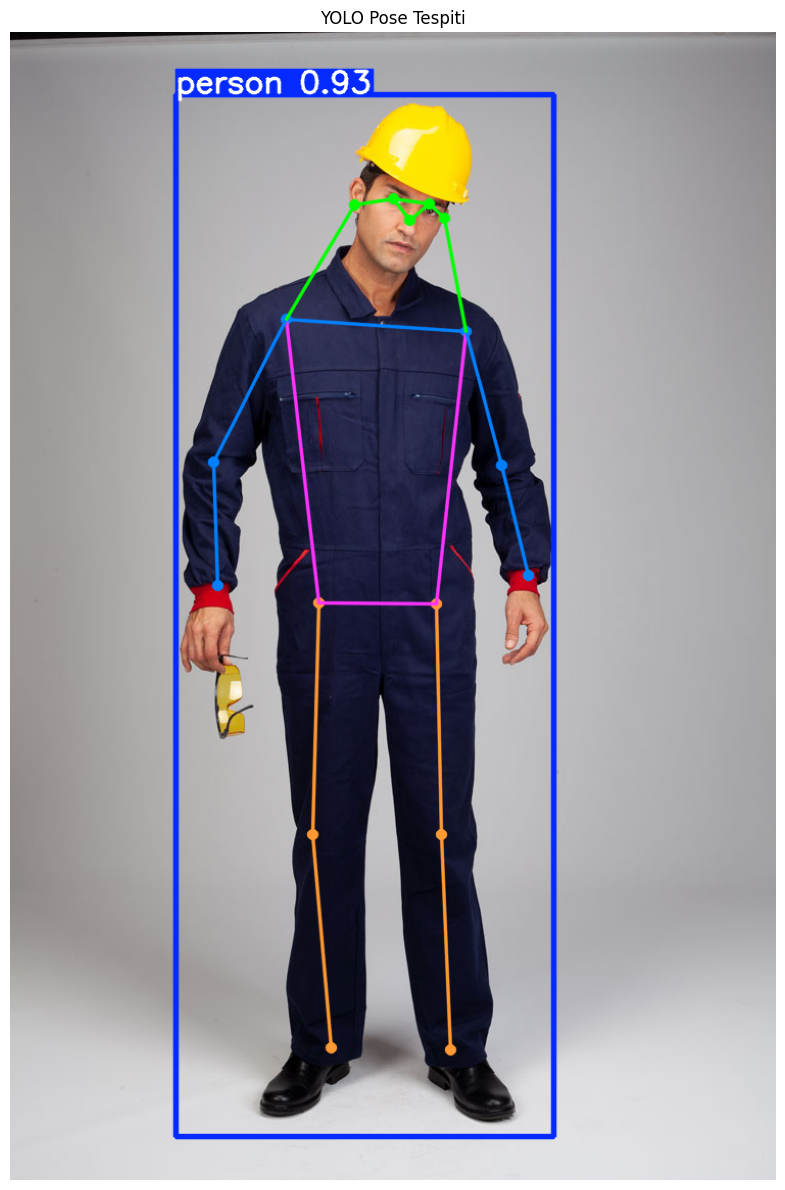

In [5]:
# YOLO sonucunu gorsellestir
import matplotlib.pyplot as plt

if rendered_img is not None:
    plt.figure(figsize=(10, 12))
    plt.imshow(cv2.cvtColor(rendered_img, cv2.COLOR_BGR2RGB))
    plt.title("YOLO Pose Tespiti")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Gorsellestirme yapilamadi.")

## 3. Keypoint'lerden DataFrame Olusturma ve Aci Hesaplama

YOLO ciktisindaki keypoint'leri DataFrame'e donusturup, `add_pose_angles` fonksiyonu ile
3D ve duzlemsel (XY, XZ, YZ) eklem acilarini hesapliyoruz.

Bu acilar FT-Transformer modeline input olarak verilecek.

In [6]:
def keypoints_to_dataframe(result_dict, person_idx=0):
    """
    YOLO pose ciktisini pandas DataFrame'e donusturur.
    Ilk kisi (person_idx=0) varsayilan olarak alinir.
    """
    inst_list = result_dict.get("instance_info", [])
    if not inst_list or person_idx >= len(inst_list):
        raise ValueError("Belirtilen kisi bulunamadi.")

    keypoints = inst_list[person_idx]["keypoints"]

    if len(keypoints) < 17:
        keypoints += [[0.0, 0.0, 0.0]] * (17 - len(keypoints))

    input_row = {}
    for i, name in enumerate(KEYPOINT_NAMES):
        x, y, z = keypoints[i]
        input_row[f"{name}_x"] = x
        input_row[f"{name}_y"] = y
        input_row[f"{name}_z"] = z

    df = pd.DataFrame([input_row])
    df.columns = BASE_INPUT_COLS
    return df


# Keypoint'leri DataFrame'e cevir
df_keypoints = keypoints_to_dataframe(result_dict)
print(f"Keypoint DataFrame boyutu: {df_keypoints.shape}")
print(f"\nIlk birkac kolon:")
df_keypoints.iloc[:, :9]

Keypoint DataFrame boyutu: (1, 51)

Ilk birkac kolon:


,nose_x,nose_y,nose_z,left_eye_x,left_eye_y,left_eye_z,right_eye_x,right_eye_y,right_eye_z
0,391.486969,184.185257,0.998186,410.098022,168.460419,0.985938,375.493469,163.279419,0.994454


In [7]:
# Eklem acilarini hesapla (3D + XY/XZ/YZ duzlemsel projeksiyon acilari)
df_input = add_pose_angles(df_keypoints, add_planar_angles=True)

# Model icin input kolonlarini guncelle
input_cols = df_input.columns.tolist()

print(f"Aci hesaplamasi sonrasi kolon sayisi: {len(input_cols)}")
print(f"  - Temel keypoint: 51")
print(f"  - Hesaplanan acilar: {len(input_cols) - 51}")
print(f"\nEklenen aci kolonlari:")
for col in input_cols[51:]:
    val = df_input[col].iloc[0]
    print(f"  {col}: {val:.2f}" if not pd.isna(val) else f"  {col}: NaN")

Aci hesaplamasi sonrasi kolon sayisi: 90
  - Temel keypoint: 51
  - Hesaplanan acilar: 39

Eklenen aci kolonlari:
  left_elbow_angle_3d: 178.63
  right_elbow_angle_3d: 151.27
  left_shoulder_angle_3d: 21.13
  right_shoulder_angle_3d: 33.55
  left_hip_angle_3d: 172.25
  right_hip_angle_3d: 171.86
  left_knee_angle_3d: 178.93
  right_knee_angle_3d: 173.52
  trunk_vs_left_thigh_angle_3d: 178.85
  trunk_vs_right_thigh_angle_3d: 178.17
  neck_vs_trunk_angle_3d: 17.86
  shoulder_line_vs_hip_line_angle_3d: 3.78
  left_elbow_angle_xy: 178.63
  right_elbow_angle_xy: 151.27
  left_shoulder_angle_xy: 21.13
  right_shoulder_angle_xy: 33.55
  left_hip_angle_xy: 172.25
  right_hip_angle_xy: 171.86
  left_knee_angle_xy: 178.93
  right_knee_angle_xy: 173.52
  shoulder_line_vs_hip_line_angle_xy: 3.78
  left_elbow_angle_xz: 179.99
  right_elbow_angle_xz: 0.02
  left_shoulder_angle_xz: 179.99
  right_shoulder_angle_xz: 180.00
  left_hip_angle_xz: 0.00
  right_hip_angle_xz: 0.00
  left_knee_angle_xz: 179.

## 4. FT-Transformer Modeli ile Gizli Acilarin Tahmini

Blender'da 3D insan modelleri uzerinden egitilen FT-Transformer modeli,
2D keypoint verisinden **gizli/gorunmeyen vucut acilarini** ve **lokal quaternion degerlerini** tahmin eder.

Model mimarisi:
- Feature Tokenizer → Positional Embedding → 6x Transformer Block → Attention Pooling → Shared MLP → 58 target head

In [8]:
# Scaler ve modeli yukle
scaler = joblib.load(SCALER_PATH)

# Model mimarisini olustur ve uyumlu agirliklari yukle
# (Orijinal .keras dosyasi Keras 3.x formatinda kaydedilmisti,
#  convert_model.py ile Keras 2.x uyumlu .h5 formatina donusturuldu)
with open(META_PATH, 'r') as f:
    meta_info = json.load(f)

from Utils.Models import build_advanced_ft_transformer_regression

model = build_advanced_ft_transformer_regression(
    n_features=meta_info['input_dim'],
    n_targets=meta_info['n_targets'],
    d_token=96,
    n_blocks=6,
    n_heads=8,
    dropout=0.20,
    ff_mult=4,
    shared_mlp_units=(256, 128),
    per_target_hidden=64,
    use_uncertainty=meta_info['use_uncertainty']
)

# Modeli build et ve agirliklari yukle
_dummy = np.zeros((1, meta_info['input_dim']), dtype='float32')
_ = model(_dummy)
model.load_weights(r"BestModel\best_ft_transformer_multioutput_compatible.h5")

print(f"Model yuklendi (weights): BestModel\\best_ft_transformer_multioutput_compatible.h5")
print(f"Scaler yuklendi: {SCALER_PATH}")
print(f"Model input boyutu: {model.input_shape}")
print(f"Model output boyutu: {model.output_shape}")

Model yuklendi (weights): BestModel\best_ft_transformer_multioutput_compatible.h5
Scaler yuklendi: BestModel\ft_transformer_scaler.pkl
Model input boyutu: (None, 90)
Model output boyutu: (None, 58)


In [9]:
# Tahmin yap
result = predict_from_df_input(
    df_input=df_input,
    model=model,
    scaler=scaler,
    input_cols=input_cols,
    target_cols=TARGET_COLS,
    use_uncertainty=USE_UNCERTAINTY,
    batch_size=256
)

df_result, df_pred = result

print("=" * 60)
print("FT-TRANSFORMER TAHMIN SONUCLARI")
print("=" * 60)
print(f"\nToplam tahmin edilen hedef: {len(TARGET_COLS)}")
print(f"  - Aci degerleri: 19 adet")
print(f"  - Quaternion degerleri: 39 adet")
print("\n--- Tahmin Edilen Acilar ---")
print(df_pred[TARGET_COLS[:19]].T.to_string())

c:\Users\Acer\anaconda3\envs\openmmlab\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


FT-TRANSFORMER TAHMIN SONUCLARI

Toplam tahmin edilen hedef: 58
  - Aci degerleri: 19 adet
  - Quaternion degerleri: 39 adet

--- Tahmin Edilen Acilar ---
                                        0
elbowL_yz_deg                  154.695129
elbowR_yz_deg                  148.210388
head_vs_neck_xz_deg              4.429092
head_vs_neck_yz_deg             16.687502
kneeL_xz_deg                   168.429062
kneeL_yz_deg                   131.467545
kneeR_xz_deg                   169.530304
kneeR_yz_deg                   134.791351
shoulderL_vs_upperarmL_xz_deg   79.615753
shoulderL_vs_upperarmL_yz_deg  133.942734
shoulderR_vs_upperarmR_xz_deg   66.450180
shoulderR_vs_upperarmR_yz_deg  137.584869
spine1_vs_spine2_yz_deg          8.659662
spine2_vs_spine3_yz_deg          4.098736
spine3_vs_spine4_yz_deg         11.697195
thighL_vs_spine1_yz_deg        140.935272
thighR_vs_spine1_yz_deg        135.215866
wristL_yz_deg                  167.424942
wristR_yz_deg                  154.951324


## 5. REBA Skoru Hesaplama

Tahmin edilen acilar ve quaternion degerlerinden REBA (Rapid Entire Body Assessment) skoru hesaplanir.

**REBA Adimlari:**
- Step 1: Boyun (Head/Neck) skoru
- Step 2: Govde (Trunk) skoru  
- Step 3: Bacaklar (Legs/Knee) skoru
- Step 4: Ust kol (Upper Arm) skoru
- Step 5: Dirsek (Elbow) skoru
- Step 6: Bilek (Wrist) skoru

**Tablo Sistemi:**
- Table A = f(Neck, Trunk, Legs) + Force/Load
- Table B = f(Upper Arm, Lower Arm, Wrist) + Coupling
- Table C = f(Score A, Score B) + Activity Score = **Final REBA**

In [10]:
# REBA icin gerekli turetilmis kolonlari olustur
df_reba = df_result[TARGET_COLS].copy()

# Mutlak fark kolonlari (180 derece referansindan sapma)
df_reba["thighR_vs_spine1_yz_from180_abs"] = (180 - df_reba["thighR_vs_spine1_yz_deg"]).abs()
df_reba["thighL_vs_spine1_yz_from180_abs"] = (180 - df_reba["thighL_vs_spine1_yz_deg"]).abs()
df_reba["kneeR_yz_deg180_abs"] = (180 - df_reba["kneeR_yz_deg"]).abs()
df_reba["kneeL_yz_deg180_abs"] = (180 - df_reba["kneeL_yz_deg"]).abs()
df_reba["kneeR_xz_deg180_abs"] = (180 - df_reba["kneeR_xz_deg"]).abs()
df_reba["kneeL_xz_deg180_abs"] = (180 - df_reba["kneeL_xz_deg"]).abs()
df_reba["upperarmL_vs_shoulderL_yz_from180_abs"] = (180 - df_reba["shoulderL_vs_upperarmL_yz_deg"]).abs()
df_reba["upperarmR_vs_shoulderR_yz_from180_abs"] = (180 - df_reba["shoulderR_vs_upperarmR_yz_deg"]).abs()

print("Turetilmis REBA kolonlari olusturuldu.")
print(f"DataFrame boyutu: {df_reba.shape}")

Turetilmis REBA kolonlari olusturuldu.
DataFrame boyutu: (1, 66)


In [11]:
# Step 1-6 skorlarini hesapla (kurallara dayali)
df_reba_score = compute_reba_scores(df_reba, rules)

# Sadece step skorlarini al
df_reba_score = df_reba_score[["Score_Step1", "Score_Step2", "Score_Step3",
                                "Score_Step4", "Score_Step5", "Score_Step6"]].copy()

# Ek REBA parametreleri (varsayilan degerler - gerekirse degistirin)
df_reba_score["force_load_kg"] = 0          # Tasima yuku (kg)
df_reba_score["shock_or_rapid"] = False      # Ani kuvvet uygulanmasi
df_reba_score["coupling"] = 0               # Kavrama kalitesi (0=good, 1=fair, 2=poor, 3=unacceptable)
df_reba_score["static_posture"] = False      # Statik pozisyon (>1 dk ayni durusu koruma)
df_reba_score["repetitive_small_range"] = False    # Tekrarlayan kucuk hareketler
df_reba_score["rapid_large_change_or_unstable"] = False  # Hizli/dengesiz hareket

print("Step Skorlari:")
print(f"  Step 1 (Boyun):    {int(df_reba_score['Score_Step1'].iloc[0])}")
print(f"  Step 2 (Govde):    {int(df_reba_score['Score_Step2'].iloc[0])}")
print(f"  Step 3 (Bacaklar): {int(df_reba_score['Score_Step3'].iloc[0])}")
print(f"  Step 4 (Ust Kol):  {int(df_reba_score['Score_Step4'].iloc[0])}")
print(f"  Step 5 (Dirsek):   {int(df_reba_score['Score_Step5'].iloc[0])}")
print(f"  Step 6 (Bilek):    {int(df_reba_score['Score_Step6'].iloc[0])}")

Step Skorlari:
  Step 1 (Boyun):    2
  Step 2 (Govde):    6
  Step 3 (Bacaklar): 2
  Step 4 (Ust Kol):  6
  Step 5 (Dirsek):   4
  Step 6 (Bilek):    4


In [12]:
# ============================================================
# TABLE A: Neck + Trunk + Legs → Score A
# ============================================================
df_reba_score["TableA_score"] = df_reba_score.apply(
    lambda x: get_reba_tableA_score(
        neck=clamp(x["Score_Step1"], 1, 3),
        trunk=clamp(x["Score_Step2"], 1, 5),
        legs=clamp(x["Score_Step3"], 1, 4)
    ), axis=1
)

df_reba_score["ForceLoad_score"] = df_reba_score.apply(
    lambda x: get_force_load_score(
        load_value=x["force_load_kg"],
        shock_or_rapid=bool(x["shock_or_rapid"])
    ), axis=1
)

df_reba_score["ScoreA"] = df_reba_score["TableA_score"] + df_reba_score["ForceLoad_score"]

# ============================================================
# TABLE B: Upper Arm + Lower Arm + Wrist → Score B
# ============================================================
df_reba_score["TableB_score"] = df_reba_score.apply(
    lambda x: get_reba_tableB_score(
        upper_arm=clamp(x["Score_Step4"], 1, 6),
        lower_arm=clamp(x["Score_Step5"], 1, 2),
        wrist=clamp(x["Score_Step6"], 1, 3)
    ), axis=1
)

df_reba_score["Coupling_score"] = df_reba_score["coupling"].apply(get_coupling_score)
df_reba_score["ScoreB"] = df_reba_score["TableB_score"] + df_reba_score["Coupling_score"]

# ============================================================
# TABLE C: Score A + Score B → Final REBA
# ============================================================
df_reba_score["TableC_score"] = df_reba_score.apply(
    lambda x: get_reba_tableC_score(
        tableA=clamp(x["ScoreA"], 1, 12),
        tableB=clamp(x["ScoreB"], 1, 12)
    ), axis=1
)

df_reba_score["Activity_score"] = df_reba_score.apply(
    lambda x: get_activity_score(
        static_posture=x["static_posture"],
        repetitive_small_range=x["repetitive_small_range"],
        rapid_large_change_or_unstable=x["rapid_large_change_or_unstable"]
    ), axis=1
)

# FINAL REBA
df_reba_score["Final_REBA_score"] = df_reba_score["TableC_score"] + df_reba_score["Activity_score"]
df_reba_score["REBA_risk_level"] = df_reba_score["Final_REBA_score"].apply(classify_reba_risk)

print("=" * 60)
print("REBA SKOR HESAPLAMA TAMAMLANDI")
print("=" * 60)

REBA SKOR HESAPLAMA TAMAMLANDI


## 6. Sonuc Raporu ve Gorsellestirme

In [13]:
# Sonuc tablosu
cols_show = [
    "Score_Step1", "Score_Step2", "Score_Step3",
    "TableA_score", "ForceLoad_score", "ScoreA",
    "Score_Step4", "Score_Step5", "Score_Step6",
    "TableB_score", "Coupling_score", "ScoreB",
    "TableC_score", "Activity_score",
    "Final_REBA_score", "REBA_risk_level"
]

final_reba = int(df_reba_score["Final_REBA_score"].iloc[0])
risk_level = df_reba_score["REBA_risk_level"].iloc[0]

print("=" * 60)
print(f"  FINAL REBA SKORU: {final_reba}")
print(f"  RISK SEVIYESI:    {risk_level}")
print("=" * 60)
print()

# Detayli tablo
print("--- DETAYLI SKOR TABLOSU ---")
print()
print("GRUP A (Boyun + Govde + Bacaklar):")
print(f"  Boyun (Step 1):    {int(df_reba_score['Score_Step1'].iloc[0])}")
print(f"  Govde (Step 2):    {int(df_reba_score['Score_Step2'].iloc[0])}")
print(f"  Bacaklar (Step 3): {int(df_reba_score['Score_Step3'].iloc[0])}")
print(f"  Table A:           {int(df_reba_score['TableA_score'].iloc[0])}")
print(f"  Force/Load:        +{int(df_reba_score['ForceLoad_score'].iloc[0])}")
print(f"  Score A:           {int(df_reba_score['ScoreA'].iloc[0])}")
print()
print("GRUP B (Ust Kol + Dirsek + Bilek):")
print(f"  Ust Kol (Step 4):  {int(df_reba_score['Score_Step4'].iloc[0])}")
print(f"  Dirsek (Step 5):   {int(df_reba_score['Score_Step5'].iloc[0])}")
print(f"  Bilek (Step 6):    {int(df_reba_score['Score_Step6'].iloc[0])}")
print(f"  Table B:           {int(df_reba_score['TableB_score'].iloc[0])}")
print(f"  Coupling:          +{int(df_reba_score['Coupling_score'].iloc[0])}")
print(f"  Score B:           {int(df_reba_score['ScoreB'].iloc[0])}")
print()
print("FINAL:")
print(f"  Table C:           {int(df_reba_score['TableC_score'].iloc[0])}")
print(f"  Activity:          +{int(df_reba_score['Activity_score'].iloc[0])}")
print(f"  FINAL REBA:        {final_reba}")
print(f"  RISK:              {risk_level}")

  FINAL REBA SKORU: 10
  RISK SEVIYESI:    High risk

--- DETAYLI SKOR TABLOSU ---

GRUP A (Boyun + Govde + Bacaklar):
  Boyun (Step 1):    2
  Govde (Step 2):    6
  Bacaklar (Step 3): 2
  Table A:           7
  Force/Load:        +0
  Score A:           7

GRUP B (Ust Kol + Dirsek + Bilek):
  Ust Kol (Step 4):  6
  Dirsek (Step 5):   4
  Bilek (Step 6):    4
  Table B:           9
  Coupling:          +0
  Score B:           9

FINAL:
  Table C:           10
  Activity:          +0
  FINAL REBA:        10
  RISK:              High risk


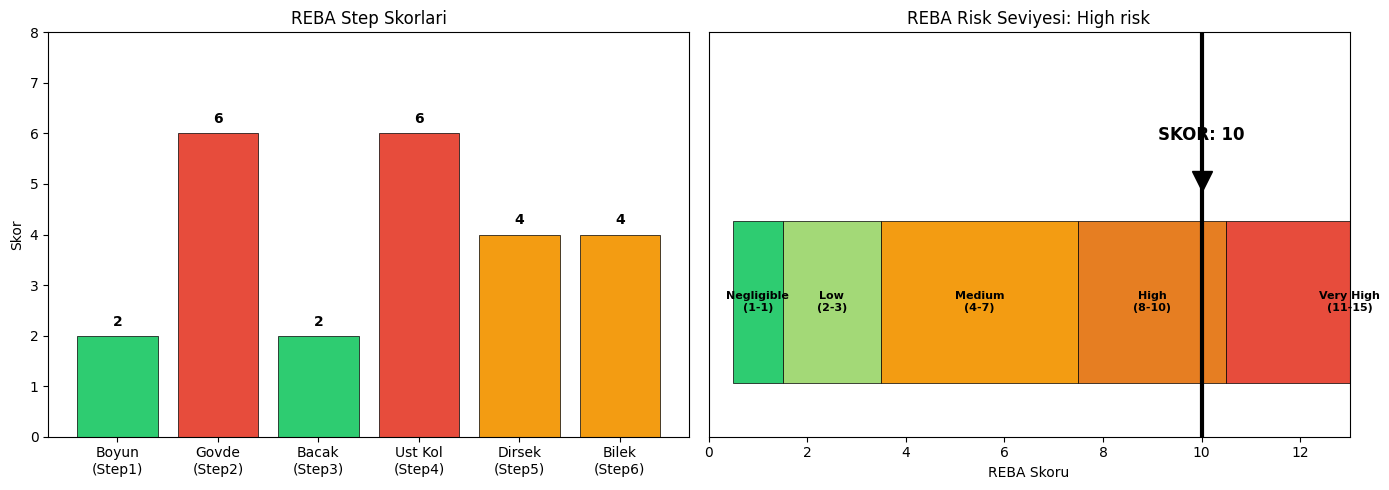


Gorsel kaydedildi: Output\reba_sonuc.png


In [14]:
# REBA risk seviyesi gorsellestirmesi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Step skorlari bar chart
step_names = ["Boyun\n(Step1)", "Govde\n(Step2)", "Bacak\n(Step3)", 
              "Ust Kol\n(Step4)", "Dirsek\n(Step5)", "Bilek\n(Step6)"]
step_values = [
    int(df_reba_score['Score_Step1'].iloc[0]),
    int(df_reba_score['Score_Step2'].iloc[0]),
    int(df_reba_score['Score_Step3'].iloc[0]),
    int(df_reba_score['Score_Step4'].iloc[0]),
    int(df_reba_score['Score_Step5'].iloc[0]),
    int(df_reba_score['Score_Step6'].iloc[0]),
]
colors = ['#2ecc71' if v <= 2 else '#f39c12' if v <= 4 else '#e74c3c' for v in step_values]

axes[0].bar(step_names, step_values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel("Skor")
axes[0].set_title("REBA Step Skorlari")
axes[0].set_ylim(0, max(step_values) + 2)
for i, v in enumerate(step_values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# Sag: REBA risk olcegi
risk_levels = [
    ("Negligible", 1, 1, '#2ecc71'),
    ("Low", 2, 3, '#a3d977'),
    ("Medium", 4, 7, '#f39c12'),
    ("High", 8, 10, '#e67e22'),
    ("Very High", 11, 15, '#e74c3c'),
]

y_pos = 0
for name, low, high, color in risk_levels:
    width = high - low + 1
    rect = axes[1].barh(0, width, left=low-0.5, height=0.6, color=color, edgecolor='black', linewidth=0.5)
    axes[1].text(low + width/2 - 0.5, 0, f"{name}\n({low}-{high})", 
                ha='center', va='center', fontsize=8, fontweight='bold')

# Mevcut skor isaretcisi
axes[1].axvline(x=final_reba, color='black', linewidth=3, linestyle='-')
axes[1].plot(final_reba, 0.45, 'v', color='black', markersize=15)
axes[1].text(final_reba, 0.6, f"SKOR: {final_reba}", ha='center', fontweight='bold', fontsize=12)

axes[1].set_xlim(0, 13)
axes[1].set_ylim(-0.5, 1)
axes[1].set_xlabel("REBA Skoru")
axes[1].set_title(f"REBA Risk Seviyesi: {risk_level}")
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "reba_sonuc.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nGorsel kaydedildi: {os.path.join(OUTPUT_FOLDER, 'reba_sonuc.png')}")

## 7. Toplu Analiz (Birden Fazla Goruntu)

Bir klasordeki tum gorselleri analiz edip sonuclari tek bir tabloda toplama.

In [15]:
def analyze_single_image(image_path, model, scaler, input_cols, target_cols,
                         yolo_model_path=YOLO_MODEL_PATH, conf=YOLO_CONF):
    """
    Tek bir goruntu icin tam pipeline:
    YOLO → Aci Hesaplama → FT-Transformer → REBA
    
    Returns:
        dict: Tum sonuclari iceren sozluk
    """
    # 1. YOLO Pose
    result_dict, _ = yolo_pose_extract(image_path, yolo_model_path, conf)
    if not result_dict or not result_dict["instance_info"]:
        return {"image": os.path.basename(image_path), "error": "Kisi tespit edilemedi"}
    
    # 2. Keypoints → DataFrame + Aci Hesaplama
    df_kp = keypoints_to_dataframe(result_dict)
    df_in = add_pose_angles(df_kp, add_planar_angles=True)
    current_input_cols = df_in.columns.tolist()
    
    # 3. FT-Transformer Tahmin
    res = predict_from_df_input(
        df_input=df_in, model=model, scaler=scaler,
        input_cols=current_input_cols, target_cols=target_cols,
        use_uncertainty=False, batch_size=256
    )
    df_res, df_p = res
    
    # 4. REBA
    df_r = df_res[target_cols].copy()
    df_r["thighR_vs_spine1_yz_from180_abs"] = (180 - df_r["thighR_vs_spine1_yz_deg"]).abs()
    df_r["thighL_vs_spine1_yz_from180_abs"] = (180 - df_r["thighL_vs_spine1_yz_deg"]).abs()
    df_r["kneeR_yz_deg180_abs"] = (180 - df_r["kneeR_yz_deg"]).abs()
    df_r["kneeL_yz_deg180_abs"] = (180 - df_r["kneeL_yz_deg"]).abs()
    df_r["kneeR_xz_deg180_abs"] = (180 - df_r["kneeR_xz_deg"]).abs()
    df_r["kneeL_xz_deg180_abs"] = (180 - df_r["kneeL_xz_deg"]).abs()
    df_r["upperarmL_vs_shoulderL_yz_from180_abs"] = (180 - df_r["shoulderL_vs_upperarmL_yz_deg"]).abs()
    df_r["upperarmR_vs_shoulderR_yz_from180_abs"] = (180 - df_r["shoulderR_vs_upperarmR_yz_deg"]).abs()
    
    df_sc = compute_reba_scores(df_r, rules)
    df_sc = df_sc[["Score_Step1", "Score_Step2", "Score_Step3",
                   "Score_Step4", "Score_Step5", "Score_Step6"]].copy()
    
    # Varsayilan parametreler
    df_sc["force_load_kg"] = 0
    df_sc["shock_or_rapid"] = False
    df_sc["coupling"] = 0
    df_sc["static_posture"] = False
    df_sc["repetitive_small_range"] = False
    df_sc["rapid_large_change_or_unstable"] = False
    
    # Table A
    tA = get_reba_tableA_score(
        neck=clamp(df_sc["Score_Step1"].iloc[0], 1, 3),
        trunk=clamp(df_sc["Score_Step2"].iloc[0], 1, 5),
        legs=clamp(df_sc["Score_Step3"].iloc[0], 1, 4)
    )
    scoreA = tA + get_force_load_score(0, False)
    
    # Table B
    tB = get_reba_tableB_score(
        upper_arm=clamp(df_sc["Score_Step4"].iloc[0], 1, 6),
        lower_arm=clamp(df_sc["Score_Step5"].iloc[0], 1, 2),
        wrist=clamp(df_sc["Score_Step6"].iloc[0], 1, 3)
    )
    scoreB = tB + get_coupling_score(0)
    
    # Table C + Final
    tC = get_reba_tableC_score(clamp(scoreA, 1, 12), clamp(scoreB, 1, 12))
    activity = get_activity_score(False, False, False)
    final_reba = tC + activity
    
    return {
        "image": os.path.basename(image_path),
        "Step1_Neck": int(df_sc["Score_Step1"].iloc[0]),
        "Step2_Trunk": int(df_sc["Score_Step2"].iloc[0]),
        "Step3_Legs": int(df_sc["Score_Step3"].iloc[0]),
        "Step4_UpperArm": int(df_sc["Score_Step4"].iloc[0]),
        "Step5_Elbow": int(df_sc["Score_Step5"].iloc[0]),
        "Step6_Wrist": int(df_sc["Score_Step6"].iloc[0]),
        "ScoreA": int(scoreA),
        "ScoreB": int(scoreB),
        "Final_REBA": int(final_reba),
        "Risk_Level": classify_reba_risk(final_reba),
    }


def analyze_folder(folder_path, model, scaler, input_cols, target_cols, extensions=(".png", ".jpg", ".jpeg")):
    """
    Bir klasordeki tum gorselleri analiz eder.
    
    Returns:
        pd.DataFrame: Her goruntu icin REBA sonuclari
    """
    from tqdm import tqdm
    
    files = sorted([
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if os.path.splitext(f)[1].lower() in extensions
    ])
    
    if not files:
        print(f"UYARI: {folder_path} klasorunde goruntu bulunamadi.")
        return pd.DataFrame()
    
    results = []
    for img_path in tqdm(files, desc="Analiz ediliyor"):
        try:
            r = analyze_single_image(img_path, model, scaler, input_cols, target_cols)
            results.append(r)
        except Exception as e:
            results.append({"image": os.path.basename(img_path), "error": str(e)})
    
    return pd.DataFrame(results)


print("Toplu analiz fonksiyonlari hazir.")
print("Kullanim: df_batch = analyze_folder('gorsel_klasoru', model, scaler, input_cols, TARGET_COLS)")

Toplu analiz fonksiyonlari hazir.
Kullanim: df_batch = analyze_folder('gorsel_klasoru', model, scaler, input_cols, TARGET_COLS)


In [16]:
# ============================================================
# ORNEK: Toplu analiz (asagidaki klasor yolunu degistirin)
# ============================================================

# BATCH_FOLDER = r"C:\Python_Output\Makehuman\Png"
# df_batch = analyze_folder(BATCH_FOLDER, model, scaler, input_cols, TARGET_COLS)
# 
# # Sonuclari kaydet
# df_batch.to_csv(os.path.join(OUTPUT_FOLDER, "batch_reba_results.csv"), index=False, encoding="utf-8-sig")
# 
# # Ozet
# print(df_batch[["image", "Final_REBA", "Risk_Level"]].to_string(index=False))
# print(f"\nOrtalama REBA: {df_batch['Final_REBA'].mean():.1f}")
# print(f"Risk dagilimi:\n{df_batch['Risk_Level'].value_counts().to_string()}")

print("Toplu analiz icin yukardaki satirlarin yorumunu kaldiriniz.")

Toplu analiz icin yukardaki satirlarin yorumunu kaldiriniz.


## 8. Sonuclari Kaydetme

In [17]:
# Tam sonuc tablosunu CSV olarak kaydet
out_csv = os.path.join(OUTPUT_FOLDER, "reba_analysis_result.csv")
df_reba_score[cols_show].to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"Sonuc CSV kaydedildi: {out_csv}")

# Tahmin edilen acilari da ayri kaydet
pred_csv = os.path.join(OUTPUT_FOLDER, "predicted_angles.csv")
df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")
print(f"Tahmin edilen acilar kaydedildi: {pred_csv}")

# JSON formatinda ozet
summary = {
    "image": os.path.basename(IMAGE_PATH),
    "final_reba_score": int(final_reba),
    "risk_level": risk_level,
    "scores": {
        "neck": int(df_reba_score['Score_Step1'].iloc[0]),
        "trunk": int(df_reba_score['Score_Step2'].iloc[0]),
        "legs": int(df_reba_score['Score_Step3'].iloc[0]),
        "upper_arm": int(df_reba_score['Score_Step4'].iloc[0]),
        "elbow": int(df_reba_score['Score_Step5'].iloc[0]),
        "wrist": int(df_reba_score['Score_Step6'].iloc[0]),
        "score_a": int(df_reba_score['ScoreA'].iloc[0]),
        "score_b": int(df_reba_score['ScoreB'].iloc[0]),
    }
}

summary_json = os.path.join(OUTPUT_FOLDER, "reba_summary.json")
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(f"JSON ozet kaydedildi: {summary_json}")

print("\n--- TAMAMLANDI ---")

Sonuc CSV kaydedildi: Output\reba_analysis_result.csv
Tahmin edilen acilar kaydedildi: Output\predicted_angles.csv
JSON ozet kaydedildi: Output\reba_summary.json

--- TAMAMLANDI ---


---

## Sistem Mimarisi Ozeti

```
┌─────────────────────────────────────────────────────────────────────┐
│                         GIRDI GORUNTUSU                              │
│                    (Fabrika/Sanayi Ortami)                           │
└─────────────────────────┬───────────────────────────────────────────┘
                          │
                          ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    YOLO11 POSE ESTIMATION                            │
│         17 Keypoint (x, y, confidence) → 51 deger                   │
└─────────────────────────┬───────────────────────────────────────────┘
                          │
                          ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    ACI HESAPLAMA (add_pose_angles)                   │
│    3D eklem acilari + XY/XZ/YZ duzlemsel projeksiyonlar             │
│    51 → 90 feature (39 hesaplanan aci eklenir)                      │
└─────────────────────────┬───────────────────────────────────────────┘
                          │
                          ▼
┌─────────────────────────────────────────────────────────────────────┐
│              FT-TRANSFORMER (Egitilmis Derin Ogrenme)               │
│                                                                     │
│  FeatureTokenizer → PositionalEmb → 6x TransformerBlock             │
│  → AttentionPooling → SharedMLP → 58 Target Head                   │
│                                                                     │
│  Cikti: 19 aci + 39 quaternion degeri                               │
│  (Blender 3D modellerinden ogrenilmis gizli acilar)                 │
└─────────────────────────┬───────────────────────────────────────────┘
                          │
                          ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    REBA SKOR HESAPLAMA                               │
│                                                                     │
│  Step 1-3 → Table A → +Force/Load → Score A                        │
│  Step 4-6 → Table B → +Coupling   → Score B                        │
│  Table C(A,B) + Activity → FINAL REBA (1-15)                       │
└─────────────────────────┬───────────────────────────────────────────┘
                          │
                          ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    RISK SINIFLANDIRMASI                              │
│                                                                     │
│  1       → Negligible risk (Ihmal edilebilir)                       │
│  2-3     → Low risk (Dusuk risk)                                    │
│  4-7     → Medium risk (Orta risk)                                  │
│  8-10    → High risk (Yuksek risk)                                  │
│  11-15   → Very high risk (Cok yuksek risk)                         │
└─────────────────────────────────────────────────────────────────────┘
```

**Projenin Yenilikci Yonu:** Blender'da 3D insan modelleri ile olusturulan sentetik veri seti sayesinde, 
2D kameradan gorunmeyen vucut acilarini (omurga rotasyonlari, gizli eklem acilari) tahmin edebiliyoruz.
Bu sayede tek bir kamera goruntusu ile kapsamli REBA analizi mumkun hale geliyor.